In [19]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
from scipy.spatial.distance import pdist, squareform

from alntk.alignment import Alignment, find_sequence

# Clustering using k-means

*Written by Shoichi Yip. Last updated: 21 August 2026.*

The most straightforward approach to clustering is to use the k-means clustering algorithm.

We will convert the alignment to a format which is convenient for this purpose. This means creating a $M \times Lq$ binary array, where each sequence is made of many vectors of size $q$ which are 1 if the symbol corresponds to that index and 0 otherwise.

## Import the alignment and the red sector

Let us import the red sector.

In [2]:
red_sector = np.loadtxt("../data/iter_aln_v2_redsector.txt").astype(int)
red_sector_ordered = red_sector.copy()
red_sector_ordered.sort()

Let us import the numbering for the positions.

In [3]:
num = np.loadtxt("../data/iter_aln_v2_numbering.txt", dtype="str")

Let us import the alignment.

In [4]:
aln = Alignment()
aln.import_from_fasta("../data/iter_aln_v2.faa")

In [5]:
aln_seqs = aln.get_seqs()

Let us encode the symbols as integers.

In [6]:
alphabet = np.array(list('ACDEFGHIKLMNPQRSTVWY-'))
aa2int = {aa: i for i, aa in enumerate(alphabet)}
int2aa = {i: aa for aa, i in aa2int.items()}

In [7]:
test_aln = aln_seqs[:, red_sector_ordered].copy()
test_aln_e = np.vectorize(aa2int.get)(test_aln).astype(np.int8)

In [8]:
test_aln_e

array([[ 5, 17, 11, ...,  5, 17, 19],
       [ 5, 17, 11, ...,  5, 17, 19],
       [ 5, 17, 11, ...,  5, 17, 19],
       ...,
       [ 5, 17,  7, ..., 20, 20, 20],
       [ 2, 17, 11, ..., 20, 20, 20],
       [11, 13, 20, ..., 20, 20, 20]], shape=(89439, 17), dtype=int8)

Let us one-hot encode the alignment.

In [9]:
def one_hot_encode(arr, alphabet_length=21):
    """One-hot encode integer array of shape (n_seqs, seq_len)."""
    result = np.zeros((*arr.shape, alphabet_length), dtype=np.float32)
    # Create index grids for all dimensions
    idx = np.arange(arr.shape[0])[:, None]  # (n_seqs, 1)
    jdx = np.arange(arr.shape[1])           # (seq_len,)
    result[idx, jdx, arr] = 1
    return result.reshape(arr.shape[0], -1)

In [10]:
test_aln_ohe = one_hot_encode(test_aln_e)

## Training the k-means algorithm

We will now use the `KMeans` object from `sklearn.cluster`.

In [11]:
kmeans = KMeans(n_clusters=250)

In [12]:
kmeans.fit(test_aln_ohe)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",250
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float32](250, 

In [13]:
with open("../data/clusters_kmeans_k250.txt", "w") as f:
    for cluster_label in kmeans.labels_:
        f.write(str(cluster_label)+"\n")

In [14]:
rep_seqs_e = []

for cluster_index, cluster_center in enumerate(kmeans.cluster_centers_):
    member_indices = np.flatnonzero(kmeans.labels_ == cluster_index)
    distances = np.linalg.norm(
        test_aln_ohe[member_indices] - cluster_center,
        axis=1
    )

    closest_sequence_index = member_indices[np.argmin(distances)]
    rep_seqs_e.append(test_aln_e[closest_sequence_index])
    print(cluster_index, closest_sequence_index, test_aln_e[closest_sequence_index])

0 295 [ 5 17 19 10  0  5  5  5  2 13 18  5  5  0  5 17 19]
1 1885 [ 5  9 19 10  0  5  5  5  2 13 18  5  5  5  5 17 19]
2 10854 [11  7  2 10  5  8  5 20 15 11  4 16  9  2 16  0 19]
3 13929 [ 5  9 15 10  0  5 17 20 15 13  4 17  5 11 16 17  4]
4 18848 [ 5 17 19 10  0  5  5 15  2 13 18  5  8  5  5 17 19]
5 5661 [ 5  9  9 13 16 19  5 20  5 13 18  5 12  0  2 17  4]
6 61262 [ 5  7 19 13  0  5  5 20  2 13  9  5  5  5  5  7 19]
7 5623 [ 2 17  9 13 16  5  8  3 15 15 18  5 12  5 15 17 19]
8 4980 [ 5 17 19 10  0  5  5  5  2 13 20 20 20 20 20 20 20]
9 8961 [ 5  9 19 10  0  5  5  5  2 13  4  5  5  5  5 17 19]
10 12521 [ 5 17 19 10  0  5  8 20  2 13 18  5  5  0  5  7 19]
11 24604 [ 5 10  4 10  0  5  3 15  2 13 18  5 15  5  5  7 19]
12 82996 [11 13 18 10  0  2  8 20  2 19  4  5 11  5 15 17  4]
13 2740 [ 5 17 19 10  0  5 20 20  2 13  4  5  5  0  5 17 19]
14 898 [ 5  9  9  4  0  5  5 20  2  8 18  5  5  5  5 17 19]
15 30507 [ 5 17 19 10  0  5  3 20  2 13 18  5  5  5  5 17 19]
16 83979 [11 16 20 14 16  7 

In [15]:
rep_seqs_e = np.array(rep_seqs_e)

In [16]:
#d_condensed = pdist(rep_seqs_e, metric='hamming')
#D_full = squareform(d_condensed)

In [17]:
Z = linkage(rep_seqs_e, metric="hamming", method="average")

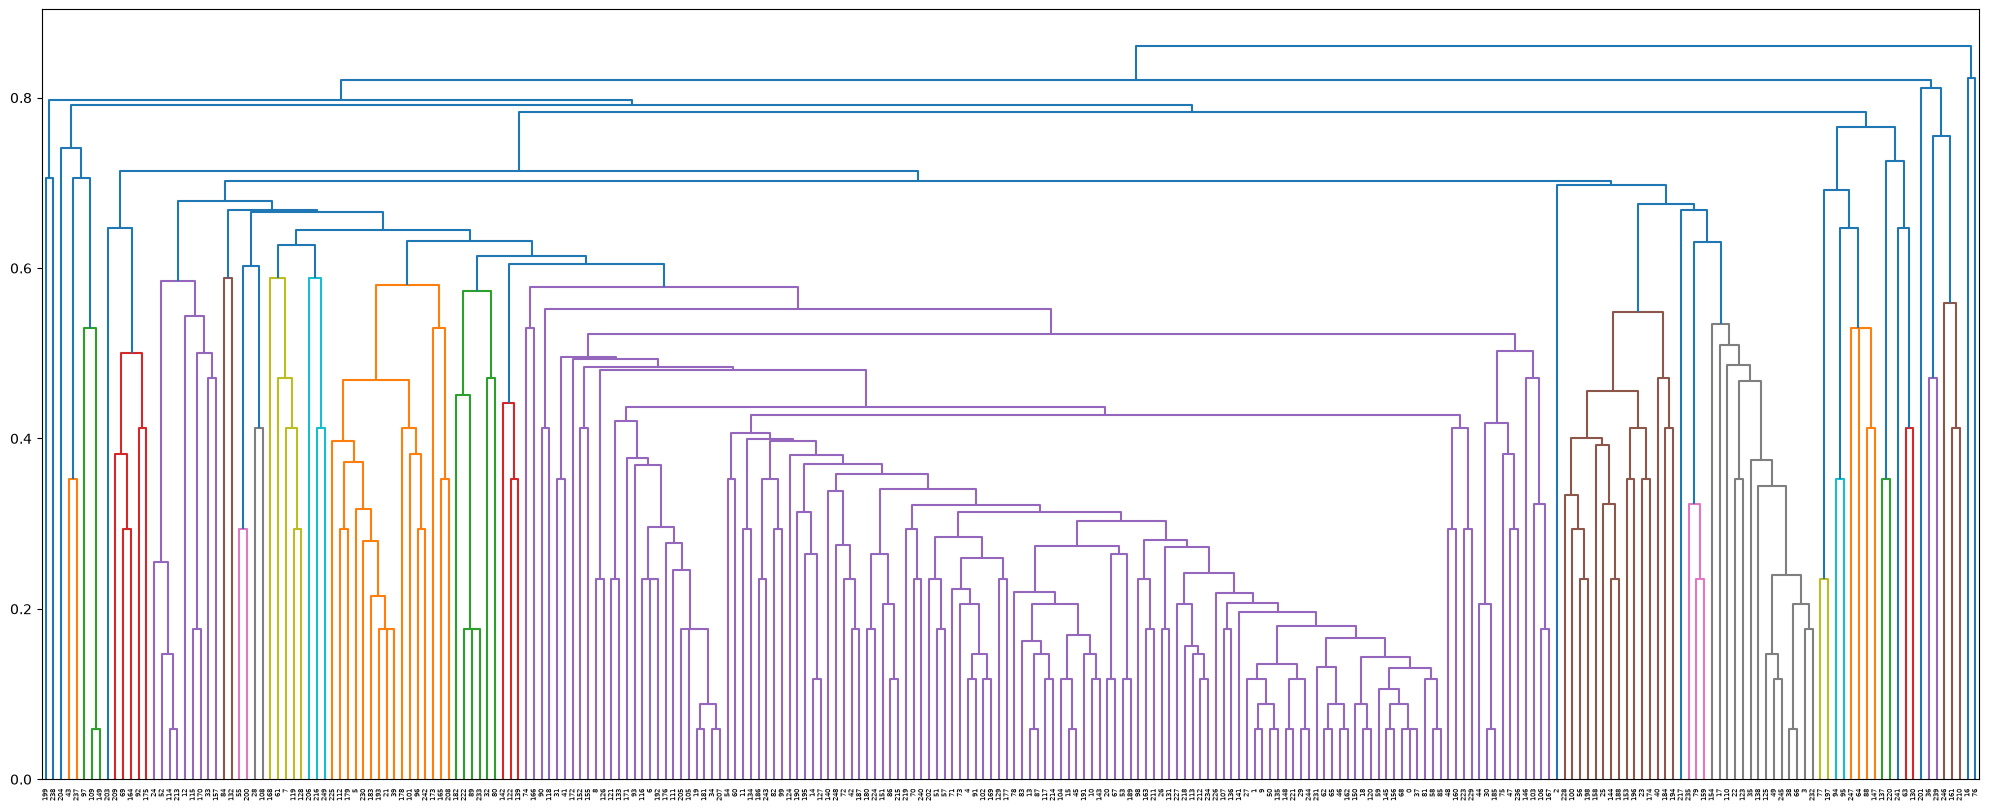

In [18]:
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Z)
plt.show()

In [22]:
new_cluster_labels = cut_tree(Z, n_clusters=100).ravel()

In [30]:
final_labels = []

for sequence_index, sequence_seq in enumerate(test_aln_e):
    first_level_label = kmeans.labels_[sequence_index]
    second_level_label = new_cluster_labels[first_level_label]
    final_labels.append(int(second_level_label))

In [34]:
final_labels = np.array(final_labels)

In [48]:
def get_consensus_sequence(aln):
    # aln is a 2D matrix, we take the unique counts per column
    n_rows, n_cols = aln.shape
    modes = np.zeros(n_cols, dtype=aln.dtype)
    for j in range(n_cols):
        col = aln[:, j]
        counts = np.bincount(col, minlength=21)
        modes[j] = np.argmax(counts)
    return modes

In [62]:
num[red_sector_ordered]

array(['18', '160', '172', '180', '183', '184', '188', '188a', '189',
       '192', '215', '216', '219', '221', '226', '227', '228'],
      dtype='<U4')

In [63]:
for final_label in range(100):
    cluster_aln = test_aln_e[np.where(final_labels == final_label)[0]]
    cluster_consensus_seq = get_consensus_sequence(cluster_aln)
    distances = np.linalg.norm(
        one_hot_encode(cluster_aln) - one_hot_encode(cluster_consensus_seq[None, :]),
        axis=1
    )
    medoid_index = np.argmin(distances)
    print("".join(np.vectorize(int2aa.get)(cluster_aln[medoid_index])))

GVYMAGGGDQWGGAGVY
NIDMGKG-SNFTLDTAY
GLDMAGV-SNFGGNTVF
GLHHTLG-GHFGPADVF
GLYQAGG-DRFGPGGVY
DVLQTGKESSWGPGSVY
GVLMAGGGDQWG-----
GVFMAGGGDQWGRGGIY
NVYMTKGGDNFGQGSVF
NT-RTIPKMFGPPSGLY
GLYMAGI-GAKNGGSVF
NLAMAGPDSQFGGISVF
GVFHTSG-GNFGGESVL
NVWVAGTKGQFNNDNVY
GLYTTSG-SSFGGQAGF
NIYQAYVEGHWAGATVY
NLWMAGA-SMWGTSAVY
GLLVAGGGDQWGGGGIF
YSYQVGIGGSYA-RGIY
GVHMTEAAGAFGGGTVY
GMDMAGG-SNFSQDAGF
NLHFTST-DKGH--SFF
NNWNLSG-SNFGGASVY
GVRMFQRGAKFSNTPVA
GIWMAGR-DNWGQGGVY
GLTMAGEDDEWGGDGFY
GVFMAGGTDMWGVFGVY
NLHHGGGGGSWSPTGVY
GLFNTSG-SNFGGEAAF
NALNSYTTGNWGPASVY
GT-DTDGVGGRGVGDIY
GLYMVEN-GIFFGESGY
GLYQVGKNSKYGKGRVF
GVLKAGSGSKLAGNGLY
GIYMAGR-GMWGGSAVF
NL---EAGGLWSGMGGF
GV-NTLRRGFFIGGDFF
GMNTAGG-SNLSTDVVF
NLYQTSG-NLYGGAGVF
GVKMAGGGDNFGKGGVY
GVYHAAG-DKGKPGSLY
GLILLAD-GNFVGGDGY
GLYQTYK-DQYGGAGVN
GIDMAHP-DDNGKGGIY
GMFEVGIKAKYGKGGVF
GVWMGVAIGSFSRGDVY
GVYMAGGGGHFGGADVY
GLWMSVK-ADYTDTQVY
GIYMAGK-GQFGPAEVY
GLYMAGTGSNWGDVSVF
GIYQANAKGNWSDATVY
GEWMTKKKGQFTDNHVF
GLNMAGNDSHWGRSTVF
NVWMVYG--KFGLNNVY
GLTMAER-DKSGVGGIY
GLLNTGGGSS

In [51]:
get_consensus_sequence(test_aln_e[np.where(final_labels == 60)[0]])

array([ 5,  9, 19, 17, 16,  5,  5, 20, 15,  8,  5,  5,  5,  5, 16,  7,  4],
      dtype=int8)

In [47]:
for s in test_aln[np.where(final_labels == 60)[0]]:
    print("".join(s))

GMYAYVDFSNVGANSIA
GINNGGP-SEETGGAAF
AMMDTQGLSYRGVNNIF
HALMTMG-STWGTGSGK
GLYITLG-SDGGPTGLY
GGD-LDS-STRGPEFIF
GTAIGDG-RYFGDQNLY
GTLLTEG-SHGGVGMRA
GTFLGSG-TQKGLKMRY
GTLITEG-SHGGVGMRA
GLFHTFG-DEFGSRGLS
GS-IGSG-SFGGTGLIF
GLLNTIG-SFWSPGNAH
GLFYTFG-DNFGTRGLS
GLWITLG-DNLGSAASF
GLFHTTG-NNFGTRGLS
GLGVTVK-SKYSLS-LF
GLFNVH--ASWGDSTAF
GTSVGGG-SDGGEGLYF
MTLFLDG-SSAGYDPYT
GNADMAS-SVQGYVFIN
GVWSTDG-NFNGGTTTF
GVWSTDG-NFGYGTTTF
GFHLTSKDSNWGGNSVF
GFHLTSKDSNWGGNSVF
GTYKVRT-SNHGRFVLY
GVVKTGG-GRVKANAAF
GLLVGGG-SNWGNQTAF
GMYHCYR-SESGDDAIF
HALMTMG-STWGTGSGK
GVKSTGGGNFWGSGAIF
GTYVASAGSKGGGGMLF
GLLVGGG-SNWGERTAF
GTFIGGG-SYGGGGLYF
GTLMTRG-SHGGVGMRF
GQRLTLG-SHGGIGMYY
GTYQTQ--ADYSDSSAF
GTLMTRG-SHGGVGMRF
GLANTHGEGFFGQATSF
GINSTGGGNFWGSGAIF
GLLVGGG-SNWGERTAF
NLLVGGG-SNWGASTAF
GLLVGSG-SNWGSRTAF
GMMVAEGESQWGDAEIL
GT-VASG-SFGGTGLYF
GMVSTEG-SHGGKGMRF
GQ-QVEN-TKRALATIF
GTYVTGG-SKGGKAMLF
GAFQTGG-NSIGKESAH
GLINGYT-SYWGGATAF
GTYVTGG-SKGGKALLF
GLNYGYT-SMWGTDTAF
GTYVTSG-SKGGKALLF
GTEIADG-SKGGEGLLF
GLFQTQR-SFFGVDTIF
GLLVGGN-SN